# Stage-1 unmatched-vs-matched Lund DNN classifier

This notebook trains the **Stage-1 classifier** for the two-stage approach:

| Stage-1 label | Original `channel2` | Meaning |
|---:|---|---|
| 0 | 0 | unmatched |
| 1 | 1, 2, 3 | matched: `qqbar`, `qg`, or `gg-like` |

It drops `channel2 == 4` (`rest`) and keeps `channel2 == 0, 1, 2, 3`.
Everything else follows the same structure as the Stage-2 notebook: same input variables, same event-level split, same preprocessing, same DNN style, same class-weight strategy, and same evaluation style.

`dpsi12` is not used as an input feature. It is kept only for post-training physics plots.


In [1]:

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import dump, load
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "TensorFlow is required for this notebook. Install it with: pip install tensorflow"
    ) from exc

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.16.2


## 1. Paths

Change `CSV_PATH` if your file is somewhere else. The fallback list includes the uploaded sandbox path and common local names.

In [2]:
CSV_PATH = Path("merged_ML-pb80-0GeV.csv")

fallback_paths = [
    Path("merged_ML-pb80-0GeV.csv"),
    Path("merged_ML-pb80-0GeV(1).csv"),
    Path("../csv/merged_ML-pb80-0GeV.csv"),
    Path("../merged_ML-pb80-0GeV.csv"),
    Path("/mnt/data/merged_ML-pb80-0GeV.csv"),
]

if not CSV_PATH.exists():
    for path in fallback_paths:
        if path.exists():
            CSV_PATH = path
            break

if not CSV_PATH.exists():
    raise FileNotFoundError(
        "Could not find merged_ML.csv. Set CSV_PATH to the location of your CSV."
    )

MODEL_DIR = Path("models_stage1_unmatched_vs_matched_pbpb")
OUTPUT_DIR = Path("outputs_stage1_unmatched_vs_matched_pbpb")
MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print("Using CSV:", CSV_PATH.resolve())
print("Stage-1 model directory:", MODEL_DIR.resolve())
print("Stage-1 output directory:", OUTPUT_DIR.resolve())


Using CSV: /Users/alexmendonca/Desktop/pic2/csv/merged_ML-pb80-0GeV.csv
Stage-1 model directory: /Users/alexmendonca/Desktop/pic2/python/models_stage1_unmatched_vs_matched_pbpb
Stage-1 output directory: /Users/alexmendonca/Desktop/pic2/python/outputs_stage1_unmatched_vs_matched_pbpb


## 2. Load CSV and build features

The DNN inputs are the same as in the Stage-2 notebook.  
The original target is `channel2`, but for Stage 1 we convert it into a binary target:

- `channel2 == 0` → `0 = unmatched`
- `channel2 in [1, 2, 3]` → `1 = matched`

`dpsi12` is explicitly excluded from the DNN inputs.


In [3]:

def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add stable transformed and combination features.

    Important: this function does not touch dpsi12 except keeping it available
    for post-training plots.
    """
    df = df.copy()

    # Stabilize long-tailed positive variables.
    for col in ["pt_dispersion3", "pt_dispersion4"]:
        if col in df.columns:
            df[col] = np.log1p(df[col].clip(lower=0))

    if "kt2" in df.columns:
        df["kt2"] = np.log1p(df["kt2"].clip(lower=0))

    if "deltaR34" in df.columns:
        dr = df["deltaR34"].clip(lower=1e-4)
        df["deltaR34"] = np.log1p(1.0 / dr)

    # z variables
    df["z_sum"] = df["z1"] + df["z2"]
    df["z_absdiff"] = np.abs(df["z1"] - df["z2"])
    df["z_min"] = np.minimum(df["z1"], df["z2"])
    df["z_max"] = np.maximum(df["z1"], df["z2"])
    df["z_minmax_ratio"] = df["z_min"] / (df["z_max"] + 1e-8)

    # Pairwise subjet observables. Use sum/absdiff/min/max/ratio to avoid relying
    # too much on arbitrary subjet-3/subjet-4 ordering.
    paired_bases = [
        ("N_charged3", "N_charged4", "N_charged"),
        ("N_all3", "N_all4", "N_all"),
        ("pt_weight3", "pt_weight4", "pt_weight"),
        ("pt_dispersion3", "pt_dispersion4", "pt_dispersion"),
    ]

    for c3, c4, name in paired_bases:
        if c3 not in df.columns or c4 not in df.columns:
            continue
        v3 = df[c3]
        v4 = df[c4]
        vmin = np.minimum(v3, v4)
        vmax = np.maximum(v3, v4)
        df[f"{name}_sum"] = v3 + v4
        df[f"{name}_absdiff"] = np.abs(v3 - v4)
        df[f"{name}_min"] = vmin
        df[f"{name}_max"] = vmax
        df[f"{name}_minmax_ratio"] = vmin / (vmax + 1e-8)

    return df


df_raw = pd.read_csv(CSV_PATH)
print("Raw shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())

# Keep this the same as your Stage-2 notebook.
# If you want the engineered-feature version, switch to: df = add_engineered_features(df_raw)
#df = add_engineered_features(df_raw)
df = df_raw.copy()

ORIGINAL_TARGET = "channel2"
if ORIGINAL_TARGET not in df.columns:
    raise ValueError(f"Missing target column {ORIGINAL_TARGET!r}")

df = df.dropna(subset=[ORIGINAL_TARGET]).copy()
df[ORIGINAL_TARGET] = df[ORIGINAL_TARGET].astype(int)

print("Original channel2 counts:")
display(df[ORIGINAL_TARGET].value_counts().sort_index().rename("count").to_frame())


Raw shape: (24473, 18)
Columns: ['Event', 'Jet', 'Jet_pt', 'z1', 'z2', 'deltaR34', 'kt2', 'N_charged3', 'N_charged4', 'N_all3', 'N_all4', 'pt_weight3', 'pt_weight4', 'pt_dispersion3', 'pt_dispersion4', 'tau_time', 'channel2', 'dpsi12']
Original channel2 counts:


,count
channel2,
0,22677
1,122
2,578
3,870
4,226


## 3. Select Stage-1 classes and define training inputs

Stage-1 behavior:

- Keep `channel2 = 0, 1, 2, 3`
- Drop `channel2 = 4` (`rest`)
- Remap labels: `0 -> 0` unmatched, `1/2/3 -> 1` matched
- Drop identifiers and non-input variables: `Event`, `Jet`, `tau_time`, `dpsi12`, `channel2`, `stage1_target`


In [4]:

# Stage 1: unmatched vs matched.
# Original labels:
#   channel2 = 0 -> unmatched
#   channel2 = 1,2,3 -> matched
KEEP_ORIGINAL_CLASSES = [0, 1, 2, 3]
df = df[df[ORIGINAL_TARGET].isin(KEEP_ORIGINAL_CLASSES)].copy()

STAGE1_TARGET = "stage1_target"
df[STAGE1_TARGET] = (df[ORIGINAL_TARGET] != 0).astype(np.int64)

CLASS_NAMES = {
    0: "unmatched",
    1: "matched",
}
ORIGINAL_CLASS_NAMES = {
    0: "unmatched",
    1: "qqbar",
    2: "qg",
    3: "gg-like",
}
expected_classes = np.array([0, 1], dtype=np.int64)

print("Counts after dropping rest and keeping original channel2 = 0,1,2,3:")
display(df[ORIGINAL_TARGET].value_counts().sort_index().rename("count").to_frame())
print("Fractions in original labels:")
display((100 * df[ORIGINAL_TARGET].value_counts(normalize=True).sort_index()).rename("percent").to_frame())

print("\nStage-1 binary target counts:")
display(df[STAGE1_TARGET].value_counts().sort_index().rename("count").to_frame())
print("Stage-1 binary target fractions:")
display((100 * df[STAGE1_TARGET].value_counts(normalize=True).sort_index()).rename("percent").to_frame())

# Never use dpsi12 as an input feature.
ADDITIONAL_COLUMNS_TO_DROP = ["Event", "Jet", "dpsi12", "tau_time","Jet_pt"]
columns_to_drop = sorted(
    set([ORIGINAL_TARGET, STAGE1_TARGET] + ADDITIONAL_COLUMNS_TO_DROP),
    key=lambda col: list(df.columns).index(col) if col in df.columns else 10**9,
)

feature_columns = [col for col in df.columns if col not in columns_to_drop]

# Keep only numeric features.
X = df[feature_columns].copy()
non_numeric_columns = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_columns:
    raise ValueError(f"Non-numeric feature columns found: {non_numeric_columns}")

# Replace inf with nan so the imputer can handle them.
X = X.replace([np.inf, -np.inf], np.nan)
y = df[STAGE1_TARGET].to_numpy(dtype=np.int64)
y_original = df[ORIGINAL_TARGET].to_numpy(dtype=np.int64)

print("Dropped columns:", columns_to_drop)
print("Number of features:", len(feature_columns))
print("Feature columns:")
for c in feature_columns:
    print("  -", c)

assert "dpsi12" not in feature_columns
assert ORIGINAL_TARGET not in feature_columns
assert STAGE1_TARGET not in feature_columns


Counts after dropping rest and keeping original channel2 = 0,1,2,3:


,count
channel2,
0,22677
1,122
2,578
3,870


Fractions in original labels:


,percent
channel2,
0,93.524972
1,0.503155
2,2.383800
3,3.588073



Stage-1 binary target counts:


,count
stage1_target,
0,22677
1,1570


Stage-1 binary target fractions:


,percent
stage1_target,
0,93.524972
1,6.475028


Dropped columns: ['Event', 'Jet', 'Jet_pt', 'tau_time', 'channel2', 'dpsi12', 'stage1_target']
Number of features: 12
Feature columns:
  - z1
  - z2
  - deltaR34
  - kt2
  - N_charged3
  - N_charged4
  - N_all3
  - N_all4
  - pt_weight3
  - pt_weight4
  - pt_dispersion3
  - pt_dispersion4


## 4. Event-level train/validation/test split and preprocessing

Splitting by event is safer than row-wise random splitting because it avoids putting jets from the same event in both train and test.

This split is performed after dropping `rest`, but before any preprocessing is fitted.

In [5]:

USE_EVENT_GROUP_SPLIT = "Event" in df.columns

if USE_EVENT_GROUP_SPLIT:
    groups = df["Event"].to_numpy()

    splitter_test = GroupShuffleSplit(n_splits=1, test_size=0.33, random_state=RANDOM_STATE)
    trainval_idx, test_idx = next(splitter_test.split(X, y, groups=groups))

    X_trainval = X.iloc[trainval_idx]
    X_test = X.iloc[test_idx]
    y_trainval = y[trainval_idx]
    y_test = y[test_idx]
    y_original_trainval = y_original[trainval_idx]
    y_original_test = y_original[test_idx]
    groups_trainval = groups[trainval_idx]

    splitter_val = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=RANDOM_STATE + 1)
    train_rel_idx, val_rel_idx = next(splitter_val.split(X_trainval, y_trainval, groups=groups_trainval))

    X_train = X_trainval.iloc[train_rel_idx]
    X_val = X_trainval.iloc[val_rel_idx]
    y_train = y_trainval[train_rel_idx]
    y_val = y_trainval[val_rel_idx]
    y_original_train = y_original_trainval[train_rel_idx]
    y_original_val = y_original_trainval[val_rel_idx]
else:
    print("No Event column found. Falling back to stratified row-wise split.")
    X_trainval, X_test, y_trainval, y_test, y_original_trainval, y_original_test = train_test_split(
        X, y, y_original, test_size=0.15, random_state=RANDOM_STATE, stratify=y,
    )
    X_train, X_val, y_train, y_val, y_original_train, y_original_val = train_test_split(
        X_trainval, y_trainval, y_original_trainval, test_size=0.15, random_state=RANDOM_STATE, stratify=y_trainval,
    )

print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)

print("\nStage-1 class fractions:")
for name, yy in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    vc = pd.Series(yy).value_counts(normalize=True).sort_index()
    print(name)
    for c in expected_classes:
        print(f"  {CLASS_NAMES[int(c)]:>9s}: {vc.get(int(c), 0.0):.4f}")

print("\nOriginal channel2 composition in each split:")
for name, yy in [("Train", y_original_train), ("Validation", y_original_val), ("Test", y_original_test)]:
    vc = pd.Series(yy).value_counts(normalize=True).sort_index()
    print(name)
    for c in sorted(ORIGINAL_CLASS_NAMES):
        print(f"  {ORIGINAL_CLASS_NAMES[int(c)]:>9s}: {vc.get(int(c), 0.0):.4f}")

preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

X_train_pp = preprocess.fit_transform(X_train).astype("float32")
X_val_pp = preprocess.transform(X_val).astype("float32")
X_test_pp = preprocess.transform(X_test).astype("float32")

dump(preprocess, MODEL_DIR / "stage1_preprocess.joblib")

print("Preprocessed shapes:", X_train_pp.shape, X_val_pp.shape, X_test_pp.shape)


Train: (8140, 12) Validation: (8144, 12) Test: (7963, 12)

Stage-1 class fractions:
Train
  unmatched: 0.9380
    matched: 0.0620
Validation
  unmatched: 0.9349
    matched: 0.0651
Test
  unmatched: 0.9328
    matched: 0.0672

Original channel2 composition in each split:
Train
  unmatched: 0.9380
      qqbar: 0.0049
         qg: 0.0217
    gg-like: 0.0354
Validation
  unmatched: 0.9349
      qqbar: 0.0053
         qg: 0.0250
    gg-like: 0.0347
Test
  unmatched: 0.9328
      qqbar: 0.0049
         qg: 0.0247
    gg-like: 0.0375
Preprocessed shapes: (8140, 12) (8144, 12) (7963, 12)


## 5. Class weights and model definition

The class weights are softened with `alpha_power`, matching your previous notebooks. For Stage 1, increasing `alpha_power` pushes harder against the dominant class.

In [6]:

alpha_power = 0.75
classes_present = np.unique(y_train)
base_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes_present,
    y=y_train,
)
class_weight_map = {
    int(c): float(w ** alpha_power)
    for c, w in zip(classes_present, base_weights)
}

print("Base balanced class weights:", {int(c): float(w) for c, w in zip(classes_present, base_weights)})
print(f"Softened class weights with alpha_power={alpha_power}:")
print(class_weight_map)


Base balanced class weights: {0: 0.5330713817943681, 1: 8.05940594059406}
Softened class weights with alpha_power=0.75:
{0: 0.6238627077749049, 1: 4.783296182922556}


In [7]:

def make_model(input_dim: int, n_classes: int = 2) -> keras.Model:
    inputs = keras.Input(shape=(input_dim,), name="features")

    x = layers.Dense(256, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Dense(128, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.20)(x)

    x = layers.Dense(64, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.10)(x)

    outputs = layers.Dense(n_classes, activation="softmax", name="stage1_scores")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="stage1_unmatched_vs_matched_dnn")
    return model

model = make_model(input_dim=X_train_pp.shape[1], n_classes=len(expected_classes))

optimizer = keras.optimizers.Adam(learning_rate=1e-3)
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


Model: "stage1_unmatched_vs_matched_dnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_scores (Dense)           │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,402 (181.26 KB)

 Trainable params: 45,506 (177.76 KB)

 Non-trainable params: 896 (3.50 KB)

## 6. Validation metrics, checkpoint, and training

The checkpoint and early stopping monitor `val_macro_f1` by default. For Stage 1, `val_auc_matched` is also logged because the final two-stage model will use `P(matched)` as a score.

In [8]:

class ValMetricsCallback(tf.keras.callbacks.Callback):
    def __init__(self, X_val, y_val, batch_size=8192):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.batch_size = batch_size

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        y_score = self.model.predict(
            self.X_val,
            batch_size=self.batch_size,
            verbose=0,
        )
        y_pred = np.argmax(y_score, axis=1)
        p_matched = y_score[:, 1]

        logs["val_macro_f1"] = f1_score(
            self.y_val,
            y_pred,
            average="macro",
            zero_division=0,
        )
        logs["val_balanced_accuracy"] = balanced_accuracy_score(
            self.y_val,
            y_pred,
        )
        logs["val_auc_matched"] = roc_auc_score(
            (self.y_val == 1).astype(int),
            p_matched,
        )
        logs["val_pr_auc_matched"] = average_precision_score(
            (self.y_val == 1).astype(int),
            p_matched,
        )

        print(
            f" — val_macro_f1: {logs['val_macro_f1']:.4f}"
            f" — val_balanced_accuracy: {logs['val_balanced_accuracy']:.4f}"
            f" — val_auc_matched: {logs['val_auc_matched']:.4f}"
            f" — val_pr_auc_matched: {logs['val_pr_auc_matched']:.4f}"
        )


In [9]:

EPOCHS = 100
BATCH_SIZE = 1024
MONITOR_METRIC = "val_macro_f1"

val_metrics = ValMetricsCallback(X_val_pp, y_val)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(MODEL_DIR / "stage1_unmatched_vs_matched_dnn_best.keras"),
    monitor=MONITOR_METRIC,
    mode="max",
    save_best_only=True,
    save_weights_only=False,
    verbose=1,
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor=MONITOR_METRIC,
    mode="max",
    patience=15,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor=MONITOR_METRIC,
    mode="max",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1,
)

callbacks = [
    val_metrics,
    checkpoint,
    early_stop,
    reduce_lr,
]

history = model.fit(
    X_train_pp,
    y_train,
    validation_data=(X_val_pp, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_map,
    callbacks=callbacks,
    verbose=1,
)

model.save(MODEL_DIR / "stage1_unmatched_vs_matched_dnn_final.keras")

print("Best validation loss:", min(history.history["val_loss"]))
print("Best validation macro F1:", max(history.history["val_macro_f1"]))
print("Best validation balanced accuracy:", max(history.history["val_balanced_accuracy"]))
print("Best validation matched ROC-AUC:", max(history.history["val_auc_matched"]))
print("Best validation matched PR-AUC:", max(history.history["val_pr_auc_matched"]))


Epoch 1/100
1/8 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.4863 - loss: 0.9794 — val_macro_f1: 0.5018 — val_balanced_accuracy: 0.5076 — val_auc_matched: 0.6085 — val_pr_auc_matched: 0.1015

Epoch 1: val_macro_f1 improved from None to 0.50177, saving model to models_stage1_unmatched_vs_matched_pbpb/stage1_unmatched_vs_matched_dnn_best.keras

Epoch 1: finished saving model to models_stage1_unmatched_vs_matched_pbpb/stage1_unmatched_vs_matched_dnn_best.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.5251 - loss: 0.8355 - val_accuracy: 0.9295 - val_loss: 0.6013 - val_macro_f1: 0.5018 - val_balanced_accuracy: 0.5076 - val_auc_matched: 0.6085 - val_pr_auc_matched: 0.1015 - learning_rate: 0.0010
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5558 - loss: 0.7152  — val_macro_f1: 0.5065 — val_balanced_accuracy: 0.5098 — val_auc_matched: 0.6187 — val_pr_auc_matched: 0.1040

Epoch 2: val_macro_f1 improved from 0.50177 to 0.50652, saving model to models_stage1_unmatche

## 7. Training curves

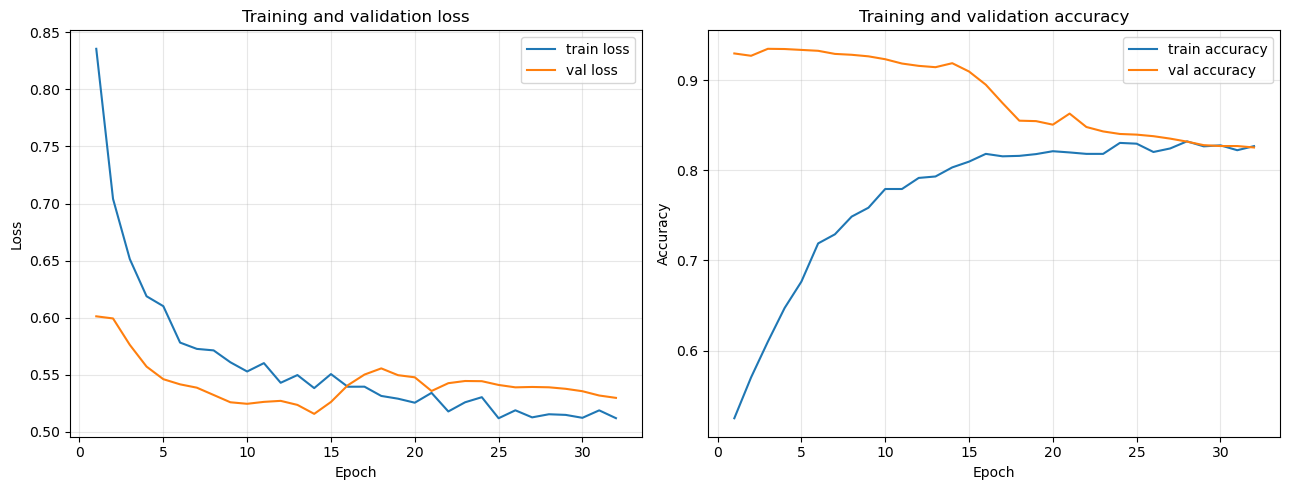

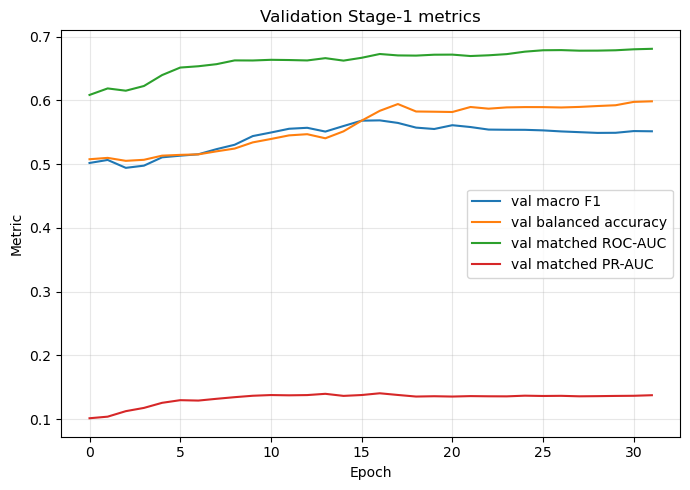

In [10]:

def plot_training_curves(history):
    hist = history.history
    epochs = np.arange(1, len(hist["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(epochs, hist["loss"], label="train loss")
    axes[0].plot(epochs, hist["val_loss"], label="val loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training and validation loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, hist["accuracy"], label="train accuracy")
    axes[1].plot(epochs, hist["val_accuracy"], label="val accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Training and validation accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=160)
    plt.show()

plot_training_curves(history)

plt.figure(figsize=(7, 5))
plt.plot(history.history["val_macro_f1"], label="val macro F1")
plt.plot(history.history["val_balanced_accuracy"], label="val balanced accuracy")
plt.plot(history.history["val_auc_matched"], label="val matched ROC-AUC")
plt.plot(history.history["val_pr_auc_matched"], label="val matched PR-AUC")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Validation Stage-1 metrics")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "validation_metrics.png", dpi=160)
plt.show()


## 8. Test-set evaluation

This evaluates the Stage-1 binary classifier with:

- classification report
- confusion matrix
- matched-vs-unmatched ROC-AUC and PR-AUC
- score distributions by true Stage-1 class


Loaded best checkpoint: models_stage1_unmatched_vs_matched_pbpb/stage1_unmatched_vs_matched_dnn_best.keras
Validation accuracy: 0.87450884086444
Validation balanced accuracy: 0.5835511545266664
Validation macro F1: 0.5685817318706909
Validation matched ROC-AUC: 0.6726537758151567
Validation matched PR-AUC: 0.1406554818829916
Test accuracy: 0.8628657541127716
Test balanced accuracy: 0.5579060538804926
Test macro F1: 0.5464800291734955
Test matched ROC-AUC: 0.6799304475613868
Test matched PR-AUC: 0.12737137831429432

Test classification report:
              precision    recall  f1-score   support

   unmatched     0.9409    0.9102    0.9253      7428
     matched     0.1416    0.2056    0.1677       535

    accuracy                         0.8629      7963
   macro avg     0.5412    0.5579    0.5465      7963
weighted avg     0.8872    0.8629    0.8744      7963



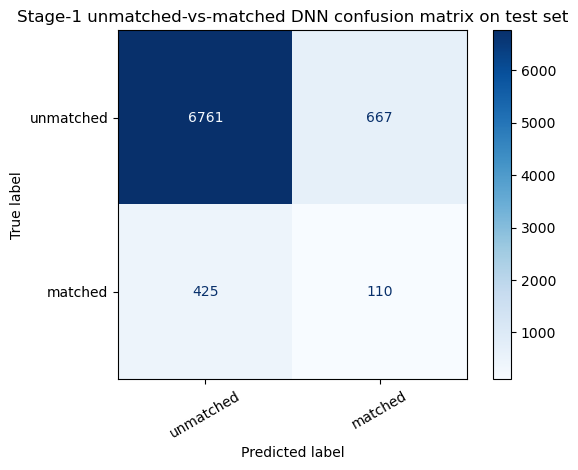

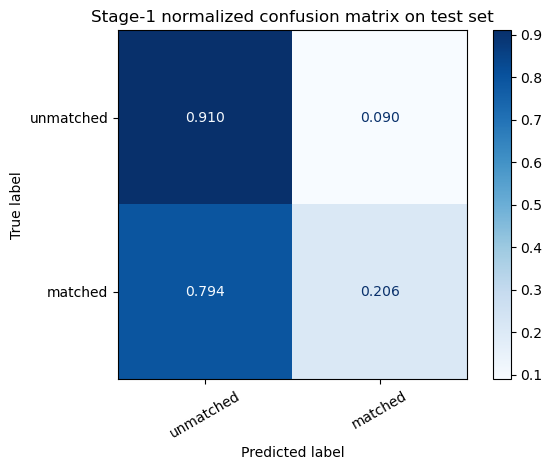

In [11]:

def predict_scores(model, X_pp):
    return model.predict(X_pp, batch_size=8192, verbose=0)

# Evaluate the checkpointed best model, not accidentally the final epoch model.
best_model_path = MODEL_DIR / "stage1_unmatched_vs_matched_dnn_best.keras"
if best_model_path.exists():
    eval_model = tf.keras.models.load_model(best_model_path)
    print("Loaded best checkpoint:", best_model_path)
else:
    eval_model = model
    print("Best checkpoint not found; using current in-memory model.")

score_val = predict_scores(eval_model, X_val_pp)
score_test = predict_scores(eval_model, X_test_pp)

pred_val = score_val.argmax(axis=1)
pred_test = score_test.argmax(axis=1)

print("Validation accuracy:", accuracy_score(y_val, pred_val))
print("Validation balanced accuracy:", balanced_accuracy_score(y_val, pred_val))
print("Validation macro F1:", f1_score(y_val, pred_val, average="macro", zero_division=0))
print("Validation matched ROC-AUC:", roc_auc_score((y_val == 1).astype(int), score_val[:, 1]))
print("Validation matched PR-AUC:", average_precision_score((y_val == 1).astype(int), score_val[:, 1]))

print("Test accuracy:", accuracy_score(y_test, pred_test))
print("Test balanced accuracy:", balanced_accuracy_score(y_test, pred_test))
print("Test macro F1:", f1_score(y_test, pred_test, average="macro", zero_division=0))
print("Test matched ROC-AUC:", roc_auc_score((y_test == 1).astype(int), score_test[:, 1]))
print("Test matched PR-AUC:", average_precision_score((y_test == 1).astype(int), score_test[:, 1]))

print("\nTest classification report:")
print(classification_report(
    y_test,
    pred_test,
    labels=expected_classes,
    target_names=[CLASS_NAMES[int(c)] for c in expected_classes],
    digits=4,
    zero_division=0,
))

cm = confusion_matrix(y_test, pred_test, labels=expected_classes)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[CLASS_NAMES[int(c)] for c in expected_classes],
)
disp.plot(values_format="d", cmap="Blues", xticks_rotation=30)
plt.title("Stage-1 unmatched-vs-matched DNN confusion matrix on test set")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "stage1_confusion_matrix_test.png", dpi=160)
plt.show()

cm_norm = confusion_matrix(y_test, pred_test, labels=expected_classes, normalize="true")
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=[CLASS_NAMES[int(c)] for c in expected_classes],
)
disp.plot(values_format=".3f", cmap="Blues", xticks_rotation=30)
plt.title("Stage-1 normalized confusion matrix on test set")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "stage1_confusion_matrix_test_normalized.png", dpi=160)
plt.show()


,positive_class,fraction,roc_auc,pr_auc
0,matched,0.067186,0.67993,0.127371


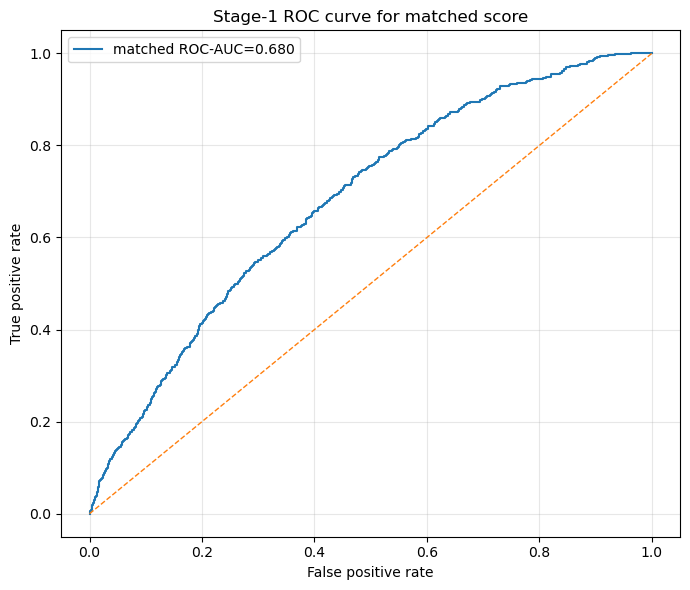

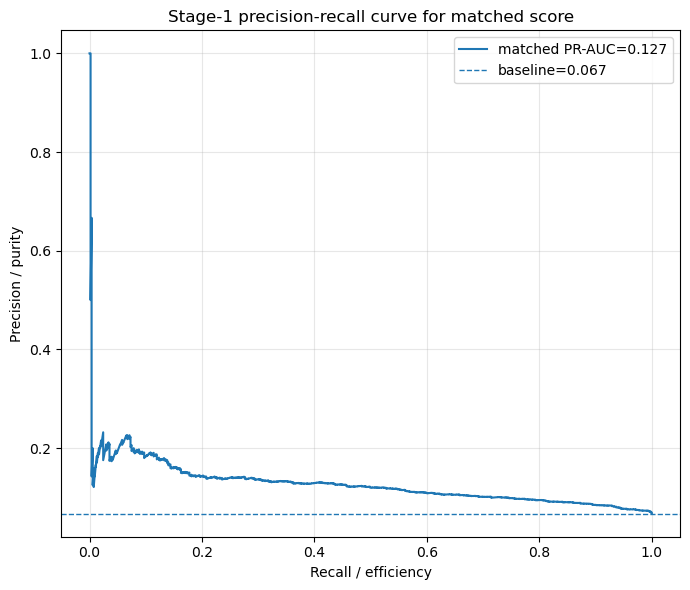

In [12]:

# Binary ROC and PR curves for P(matched)
y_true_matched = (y_test == 1).astype(int)
p_matched = score_test[:, 1]

roc = roc_auc_score(y_true_matched, p_matched)
pr = average_precision_score(y_true_matched, p_matched)
baseline = y_true_matched.mean()

metric_df = pd.DataFrame([{
    "positive_class": "matched",
    "fraction": baseline,
    "roc_auc": roc,
    "pr_auc": pr,
}])
display(metric_df)
metric_df.to_csv(OUTPUT_DIR / "stage1_matched_metrics.csv", index=False)

fpr, tpr, _ = roc_curve(y_true_matched, p_matched)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"matched ROC-AUC={roc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Stage-1 ROC curve for matched score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "stage1_roc_matched.png", dpi=160)
plt.show()

precision, recall, _ = precision_recall_curve(y_true_matched, p_matched)
plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f"matched PR-AUC={pr:.3f}")
plt.axhline(baseline, linestyle="--", linewidth=1, label=f"baseline={baseline:.3f}")
plt.xlabel("Recall / efficiency")
plt.ylabel("Precision / purity")
plt.title("Stage-1 precision-recall curve for matched score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "stage1_pr_matched.png", dpi=160)
plt.show()


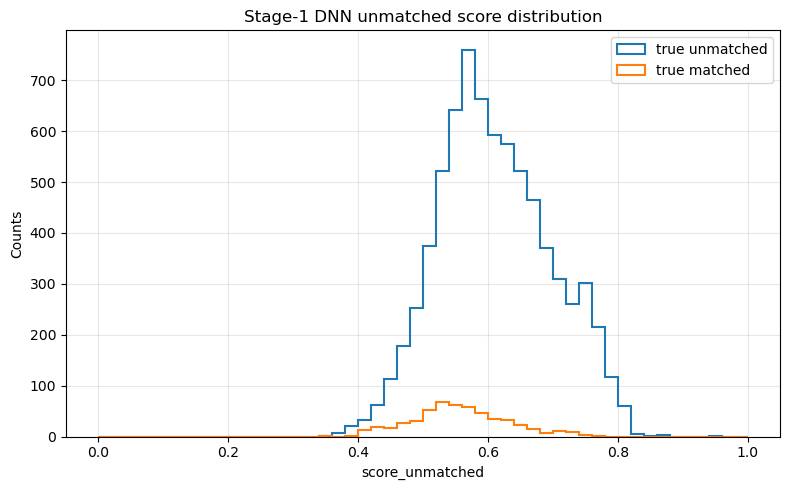

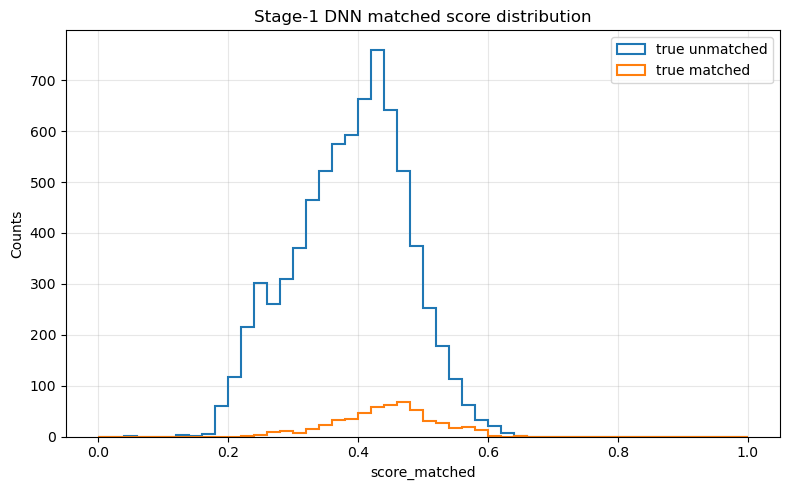

In [13]:

# Score distributions by true class
bins = np.linspace(0, 1, 51)

for c in expected_classes:
    c = int(c)
    plt.figure(figsize=(8, 5))
    for true_c in expected_classes:
        true_c = int(true_c)
        mask = y_test == true_c
        plt.hist(
            score_test[mask, c],
            bins=bins,
            histtype="step",
            density=False,
            linewidth=1.5,
            label=f"true {CLASS_NAMES[true_c]}",
            range=[0.0, 1.0],
        )
    plt.xlabel(f"score_{CLASS_NAMES[c]}")
    plt.ylabel("Counts")
    plt.title(f"Stage-1 DNN {CLASS_NAMES[c]} score distribution")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"stage1_score_distribution_class_{c}.png", dpi=160)
    plt.show()


## 9. Threshold scan for `P(matched)`

This table tells you the purity/efficiency tradeoff for cuts on the matched score.  
In the final two-stage model, you can either cut on `P(matched)` first or multiply it into the Stage-2 conditional scores.


In [14]:

rows = []
for t in np.linspace(0.05, 0.95, 91):
    selected = p_matched >= t
    if selected.sum() == 0:
        continue

    matched_purity = np.mean(y_test[selected] == 1)
    matched_efficiency = np.mean(selected[y_test == 1])
    unmatched_mistag = np.mean(selected[y_test == 0])

    rows.append({
        "threshold": t,
        "selected_fraction": selected.mean(),
        "matched_purity": matched_purity,
        "matched_efficiency": matched_efficiency,
        "unmatched_mistag_rate": unmatched_mistag,
        "n_selected": int(selected.sum()),
    })

threshold_df = pd.DataFrame(rows)
display(threshold_df)
threshold_df.to_csv(OUTPUT_DIR / "stage1_matched_threshold_scan.csv", index=False)

# Print a compact view at common thresholds.
display(threshold_df[np.isclose(threshold_df["threshold"] % 0.1, 0, atol=1e-8)].copy())


,threshold,selected_fraction,matched_purity,matched_efficiency,unmatched_mistag_rate,n_selected
0,0.05,0.999874,0.067194,1.000000,0.999865,7962
1,0.06,0.999874,0.067194,1.000000,0.999865,7962
2,0.07,0.999874,0.067194,1.000000,0.999865,7962
3,0.08,0.999874,0.067194,1.000000,0.999865,7962
4,0.09,0.999874,0.067194,1.000000,0.999865,7962
...,...,...,...,...,...,...
56,0.61,0.002260,0.166667,0.005607,0.002019,18
57,0.62,0.001381,0.181818,0.003738,0.001212,11
58,0.63,0.000879,0.285714,0.003738,0.000673,7
59,0.64,0.000502,0.500000,0.003738,0.000269,4


,threshold,selected_fraction,matched_purity,matched_efficiency,unmatched_mistag_rate,n_selected
